# Supervised Machine Learning for Classification

## Logistic Regression

In [41]:
# Requirements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc

In [2]:
# Data set
admission = pd.read_csv('c:/jilliepython/admission.csv')
admission.head()

,gender,decision,hsavg
0,0,0,77
1,1,0,79
2,1,0,82
3,0,0,81
4,0,0,88


In [3]:
# Spliting the data set into features and target variable
X = admission[['gender', 'hsavg']]
y = admission['decision']

In [ ]:
# Spliting the data set into training and test sets: 
# Stratifying train and test sets to have equal portion of success in y
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, random_state=1234)

In [5]:
# Check if the 0/1 ratio of training data and test data is similar
print(y_train.mean())
print(y_test.mean())

0.308
0.308


In [6]:
# Creating a logistic regression model
model = LogisticRegression()

In [7]:
# Traning the model using the training data
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
# Making predictions on the test set
y_pred = model.predict(X_test)

In [ ]:
# Evaluating the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\n")
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

# Strong accuracyclassification performance for both classes

Confusion Matrix:
[[170   3]
 [  4  73]]


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       173
           1       0.96      0.95      0.95        77

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250



Accuracy Score:
0.972


In [ ]:
# Predict probabilities that the class is 1
y_prob_class1 = model.predict_proba(X_test)[:, 1]

In [ ]:
# Compute ROC curve and AUC for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_prob_class1)
roc_auc = auc(fpr, tpr)
print("AUC (Class 1):", roc_auc)

# Great AUC

AUC (Class 1): 0.9895653479468509


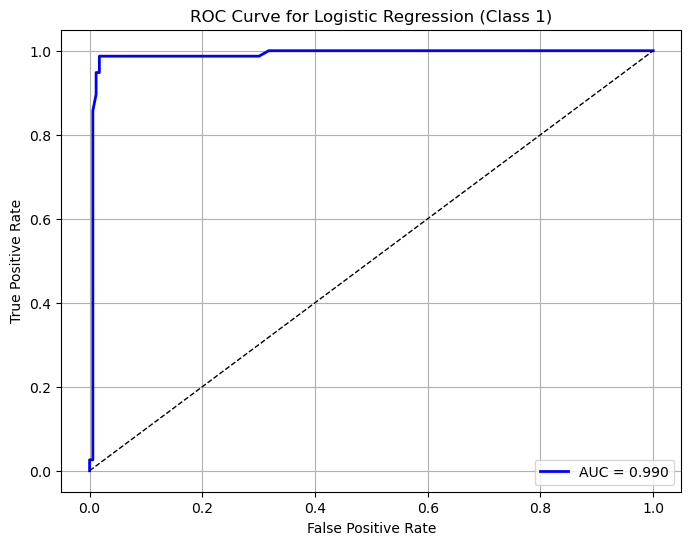

In [14]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression (Class 1)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Great ROC 

## K-Nearest Neighbors (KNN)

In [ ]:
# Classifying data using the nearest K neighbors
# Distance based, non parametric classification algorithm

In [15]:
# Requirements
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Data set
df = pd.read_csv('c:/jilliepython/mbti_and_phone.csv')
df.head()


,mbti_type,age,gender,income,smartphone,I_E,S_N,T_F,J_P
0,INFJ,50,1,95,0,1,0,0,1
1,ENFP,57,1,59,0,0,0,0,0
2,ESTJ,29,1,57,1,0,1,1,1
3,ISFJ,53,0,79,1,1,1,0,1
4,INFJ,21,1,78,0,1,0,0,1


In [20]:
# Defining the features and target variable
X = df[['I_E', 'S_N', 'T_F', 'J_P', 'age', 'gender', 'income']]
y = df['smartphone']

In [ ]:
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

In [22]:
# Standardizing the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### KNN Classification with K = 3

In [23]:
# Creating and training the KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Making predictions
y_pred = knn.predict(X_test_scaled)

In [ ]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# Higher TPR in class 1
# Lower TPR in class 0

Accuracy: 0.88
Confusion Matrix:
[[102  22]
 [ 14 162]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       124
           1       0.88      0.92      0.90       176

    accuracy                           0.88       300
   macro avg       0.88      0.87      0.88       300
weighted avg       0.88      0.88      0.88       300



### KNN Classification with K = 5

In [27]:
# Creating and training the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # Choose K
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [28]:
# Making predictions
y_pred = knn.predict(X_test_scaled)

In [ ]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# Increased K led to more balanced classification performance
# Improved TPR for class 0

Accuracy: 0.8833333333333333
Confusion Matrix:
[[104  20]
 [ 15 161]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       124
           1       0.89      0.91      0.90       176

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



## Support Vector Machine (SVM)

In [ ]:
# Classifying data by finding the optimal decision boundary
# Maximizing margins between two classes

In [30]:
# Requiremnets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
# Data set
df = pd.read_csv('c:/jilliepython/mbti_and_phone.csv')
df.head()

,mbti_type,age,gender,income,smartphone,I_E,S_N,T_F,J_P
0,INFJ,50,1,95,0,1,0,0,1
1,ENFP,57,1,59,0,0,0,0,0
2,ESTJ,29,1,57,1,0,1,1,1
3,ISFJ,53,0,79,1,1,1,0,1
4,INFJ,21,1,78,0,1,0,0,1


In [43]:
# Defining the features and target variable
X = df[['I_E', 'S_N', 'T_F', 'J_P', 'age', 'gender', 'income']]
y = df['smartphone']

In [42]:
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

In [44]:
# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Creating and training the SVM classifier
svm = SVC(kernel='linear', C=0.1)  # linear Kernel, with regularization parameter C
svm.fit(X_train_scaled, y_train)

SVC(C=0.1, kernel='linear')

In [46]:
# Making predictions
y_pred = svm.predict(X_test_scaled)

In [ ]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# Balanced performance across both classes
# Slightly lower accuracy for class 0

Accuracy: 0.85
Confusion Matrix:
[[112  17]
 [ 28 143]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       129
           1       0.89      0.84      0.86       171

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



## Decision Tree

In [53]:
# Requirements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
# Data set
df = pd.read_csv('c:/jilliepython/mbti_and_phone.csv')
df.head()

,mbti_type,age,gender,income,smartphone,I_E,S_N,T_F,J_P
0,INFJ,50,1,95,0,1,0,0,1
1,ENFP,57,1,59,0,0,0,0,0
2,ESTJ,29,1,57,1,0,1,1,1
3,ISFJ,53,0,79,1,1,1,0,1
4,INFJ,21,1,78,0,1,0,0,1


In [50]:
# Defining the features and target variable
X = df[['I_E', 'S_N', 'T_F', 'J_P', 'age', 'gender', 'income']]
y = df['smartphone']

In [51]:
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

### Random Forest with 100 Trees

In [55]:
# Requirements
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

In [56]:
# Creating random forest with 100 trees
rf_clf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    random_state=42
)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, random_state=42)

In [ ]:
# Making predictions
y_pred = rf_clf.predict(X_test)

In [ ]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("=== Random Forest (n_estimators=100) ===")
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# Strong overall performance
# Higher TPR for class 1

=== Random Forest (n_estimators=100) ===
Accuracy: 0.9066666666666666
Confusion Matrix:
[[109  20]
 [  8 163]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.84      0.89       129
           1       0.89      0.95      0.92       171

    accuracy                           0.91       300
   macro avg       0.91      0.90      0.90       300
weighted avg       0.91      0.91      0.91       300



In [ ]:
# Checking feature importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature importances:")
for i in indices:
    print(f"{X.columns[i]}: {importances[i]:.3f}")

# Top three features
# income
# S_N
# age

Feature importances:
S_N: 0.594
income: 0.100
age: 0.098
I_E: 0.079
T_F: 0.059
J_P: 0.057
gender: 0.013


### Random Forest with 300 Trees

In [61]:
# Creating random forest with 300 trees
rf_clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42
)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(min_samples_leaf=5, n_estimators=300, random_state=42)

In [62]:
# Making predictions
y_pred = rf_clf.predict(X_test)

In [ ]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("=== Random Forest (n_estimators=300) ===")
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# Improved acurracy for class 1
# Still slightly lower acurracy for class 0

# 

=== Random Forest (n_estimators=300) ===
Accuracy: 0.91
Confusion Matrix:
[[109  20]
 [  7 164]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       129
           1       0.89      0.96      0.92       171

    accuracy                           0.91       300
   macro avg       0.92      0.90      0.91       300
weighted avg       0.91      0.91      0.91       300

